# Plotting for Figure 4 with vector fields.

## Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pandas as pd
import os
from scipy.signal import find_peaks
import math

## Simulate function

In [2]:
def simulate_Ca_Na(IC,
    t=np.linspace(0, 70, 10001), 
    k=2,     
    Ki_inv=3,   
    Km_inv=0.5,      
    k_PMCA=0.8,       
    k_NCX=3.5,     
    Ck=0.5,    
    K_a=0.35,  
    k_s=0.08,     
    d=0.2,
    g=0.6,
    x0=23,     
    relative_rate=10000
    ):
    """
    Simulate the time evolution of Sodium (N) and Calcium (C) concentrations using a system of ODEs.

    Parameters
    ----------
    IC : list or array-like
    Initial conditions [N0, C0] for Sodium and Calcium concentrations.
    t : array-like, optional
    Time points for simulation (default: np.linspace(0, 70, 10001)).
    k, K1_inv, K1Ki_inv, k_PMCA, k_NCX, Ck, K_a, k_s, d, g, x0, relative_rate : float, optional
    Model parameters for the ODE system.

    Returns
    -------
    pd.DataFrame
    DataFrame with columns "Time", "Calcium", and "Sodium" containing the simulation results.
    """

    # Define the system of ODEs for Sodium and Calcium
    def deriv(t, y):
        N, C = y
        # Calculate fluxes and rates
        ip3r = (k * C) / (1 + Km_inv * C + Ki_inv * C**2) + g
        pmca = k_PMCA * C
        ncx_allo = k_NCX * math.exp(-1 * ((C - Ck) / K_a) ** 2)

        # ODEs for Calcium and Sodium
        dcdt = relative_rate * (ip3r - pmca - ncx_allo * (x0 - N))
        dndt = 3 * ncx_allo * (x0 - N) + d * (x0 - N) - k_s * N
        
        return [dndt, dcdt]

    # Solve the ODE system
    soln = solve_ivp(deriv, 
                    [min(t), max(t)], 
                    IC, 
                    t_eval=t, 
                    method='LSODA'
                    )

    # Return results as a DataFrame
    return pd.DataFrame({"Time": soln.t, 
                "Calcium": soln.y[1, :], 
                "Sodium": soln.y[0, :]
                })

In [3]:


def simulate_Ca_Na_piece(cond1, cond2, IC, tlen):
    k=cond1['k']     
    Ki_inv=cond1['Ki_inv']    
    Km_inv=cond1['Km_inv']       
    k_PMCA=cond1['k_PMCA']        
    k_NCX=cond1['k_NCX']      
    Ck=cond1['Ck']     
    K_a=cond1['K_a']   
    k_s=cond1['k_s']      
    d=cond1['d'] 
    g=cond1['g'] 
    x0=cond1['x0']      
    relative_rate=cond1['relative_rate'] 
    
    df=simulate_Ca_Na(IC, t=np.linspace(0, tlen, 10001), k=k, Ki_inv=Ki_inv, Km_inv=Km_inv, k_PMCA=k_PMCA, k_NCX=k_NCX, Ck=Ck, K_a=K_a, k_s=k_s, d=d, g=g, x0=x0, relative_rate=relative_rate)
    newIC = [df['Sodium'].iloc[-1], df['Calcium'].iloc[-1]]
    tmax = df['Time'].iloc[-1]
    
    k=cond2['k']     
    Ki_inv=cond2['Ki_inv']    
    Km_inv=cond2['Km_inv']       
    k_PMCA=cond2['k_PMCA']        
    k_NCX=cond2['k_NCX']      
    Ck=cond2['Ck']     
    K_a=cond2['K_a']   
    k_s=cond2['k_s']      
    d=cond2['d'] 
    g=cond2['g'] 
    x0=cond2['x0']      
    relative_rate=cond2['relative_rate'] 
    df2=simulate_Ca_Na(newIC, t=np.linspace(tmax, tmax+tlen, 10001), k=k, Ki_inv=Ki_inv, Km_inv=Km_inv, k_PMCA=k_PMCA, k_NCX=k_NCX, Ck=Ck, K_a=K_a, k_s=k_s, d=d, g=g, x0=x0, relative_rate=relative_rate)
    
    finaldf = pd.concat([df,df2])
    return finaldf

## Calculate derivatives onto a grid

In [4]:
# create a function to take the derivative of Ca and Na over a meshgrid
def simulate_Ca_Na_vectorfield(N_range, C_range, 
                                      k=2, Ki_inv=3, Km_inv=0.5, k_PMCA=0.8, k_NCX=3.5, 
                                      Ck=0.5, K_a=0.35, k_s=0.08, d=0.2, g=0.6, x0=23, relative_rate=10000):
     """
     Compute the derivatives dN/dt and dC/dt for a meshgrid of Sodium (N) and Calcium (C) values
     using the simulate_Ca_Na model.
     Returns:
          dNdt, dCdt: arrays of the same shape as the meshgrid, containing the derivatives.
     """
     N, C = np.meshgrid(N_range, C_range)
     ip3r = (k * C) / (1 + Km_inv * C + Ki_inv * C**2) + g
     pmca = k_PMCA * C
     ncx_allo = k_NCX * np.exp(-((C - Ck) / K_a) ** 2)
     dCdt = relative_rate * (ip3r - pmca - ncx_allo * (x0 - N))
     dNdt = 3 * ncx_allo * (x0 - N) + d * (x0 - N) - k_s * N
     return dNdt, dCdt


## Plot just vector fields

Text(0.5, 1.0, 'Vector Field of Sodium and Calcium Dynamics')

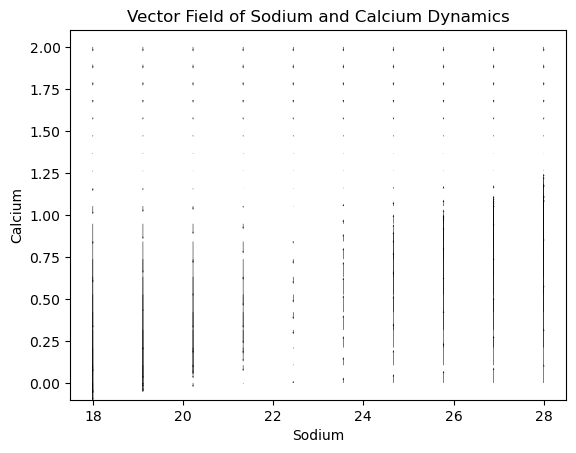

In [5]:
# Compute vector fields using the provided function
xlims = [18, 28]


N_range = np.linspace(xlims[0], xlims[1], 10)
C_range = np.linspace(0, 2, 20)
dNdt, dCdt = simulate_Ca_Na_vectorfield(
N_range, C_range)
X, Y = np.meshgrid(N_range, C_range)

plt.quiver(X, Y, dNdt, dCdt, width=0.001)
plt.xlabel('Sodium')
plt.ylabel('Calcium')
plt.title('Vector Field of Sodium and Calcium Dynamics')

## Plotting function for nullclines and vector fields

In [6]:
def plot_nullclines_w_vectorfields(
                                xlims=[20, 25],
                                k=2,
                                Ki_inv=3,
                                Km_inv=0.5,
                                k_PMCA=0.8,
                                k_NCX=3.5,
                                Ck=0.5,
                                K_a=0.35,
                                k_s=0.08,
                                d=0.2,
                                g=0.6,
                                x0=23,
                                relative_rate=2000
                                ):
    Cspan = np.linspace(0, 2, num=1000)
    C_nulcl = np.zeros(Cspan.shape[0])
    N_nulcl = np.zeros(Cspan.shape[0])

    # Compute vector fields using the provided function
    N_range = np.linspace(xlims[0], xlims[1], 10)
    C_range = np.linspace(0, 2, 10)
    dNdt, dCdt = simulate_Ca_Na_vectorfield(
    N_range, C_range,
    k=k, Ki_inv=Ki_inv, Km_inv=Km_inv, k_PMCA=k_PMCA, k_NCX=k_NCX,
    Ck=Ck, K_a=K_a, k_s=k_s, d=d, g=g, x0=x0, relative_rate=relative_rate
    )
    X, Y = np.meshgrid(N_range, C_range)

    # Compute nullclines
    for i in range(Cspan.shape[0]):
        C = Cspan[i]
        ip3r = (k * C) / (1 + Km_inv * C + Ki_inv * C ** 2) + g
        pmca = k_PMCA * C
        ncx_allo = k_NCX * math.exp(-1 * ((C - Ck) / K_a) ** 2)
        C_nulcl[i] = -1 * (ip3r - pmca) / ncx_allo + x0
        Y_ncx = 3 * ncx_allo
        N_nulcl[i] = (Y_ncx * x0 + d * x0) / (Y_ncx + k_s + d)

    # Plot vector fields and nullclines
    # Vector field using plt.quiver(Na, Ca, dNdt, dCdt)
    plt.quiver(X, Y, dNdt, dCdt, color='black', label='Vector Field') # alpha=0.5)
    # Nullclines
    plt.plot(C_nulcl, Cspan, 'r', label='dCa/dt = 0')
    plt.plot(N_nulcl, Cspan, 'b', label='dNa/dt = 0')
    # Formating
    plt.legend(loc='upper right')
    plt.xlabel('Sodium Concentration')
    plt.ylabel('Calcium Concentration')
    plt.xlim(xlims)
    plt.ylim(0, 2)
    plt.grid(True)

## Put it all together

In [99]:
def calcium_sodium(N=30,
                   C=0.7,
                   t_start=0,
                   t_end=30,
                   t_points=2000,
                   k=3,
                   Ki_inv=3,
                   Km_inv=0.5,
                   k_PMCA=0.8,
                   k_NCX=5,
                   Ck=0.6,
                   K_a=0.35,
                   k_s=0.06,
                   d=0.2,
                   g=0.6,
                   x0=32,
                   relative_rate=2000,
                   ):
    # Set x-axis limits for phase plane plot
    xlims = [x0 - 5, x0 + 5]
    tgrid = np.linspace(t_start, t_end, t_points)
    
    # Simulate the system
    df = simulate_Ca_Na(IC=[N, C],
                        t=tgrid,
                        k=k,
                        Ki_inv=Ki_inv,
                        Km_inv=Km_inv,
                        k_PMCA=k_PMCA,
                        k_NCX=k_NCX,
                        Ck=Ck,
                        K_a=K_a,
                        k_s=k_s,
                        d=d,
                        g=g,
                        x0=x0,
                        relative_rate=relative_rate,
                        )
    
    

    
#    
    # Plot results
    fig, axs = plt.subplots(1,figsize=(5, 5), dpi=600)
    

    df.plot(x="Sodium", y="Calcium", ax=axs, grid=True, label='Trajectory', color='gray')
    axs.xaxis.get_label().set_visible(False)
    axs.yaxis.get_label().set_visible(False)
    axs.tick_params(labelsize=15)

    # Add nullclines and vector fields to phase plane plot
    plot_nullclines_w_vectorfields(xlims=xlims,
                    k=k,
                    Ki_inv=Ki_inv,
                    Km_inv=Km_inv,
                    k_PMCA=k_PMCA,
                    k_NCX=k_NCX,
                    Ck=Ck,
                    K_a=K_a,
                    k_s=k_s,
                    d=d,
                    g=g,
                    x0=x0,
                    relative_rate=relative_rate)
    
    # Formatting
    # axs[1].set_xlim(xlims)
    # axs[1].set_ylim(bottom=-0.05, top=2)


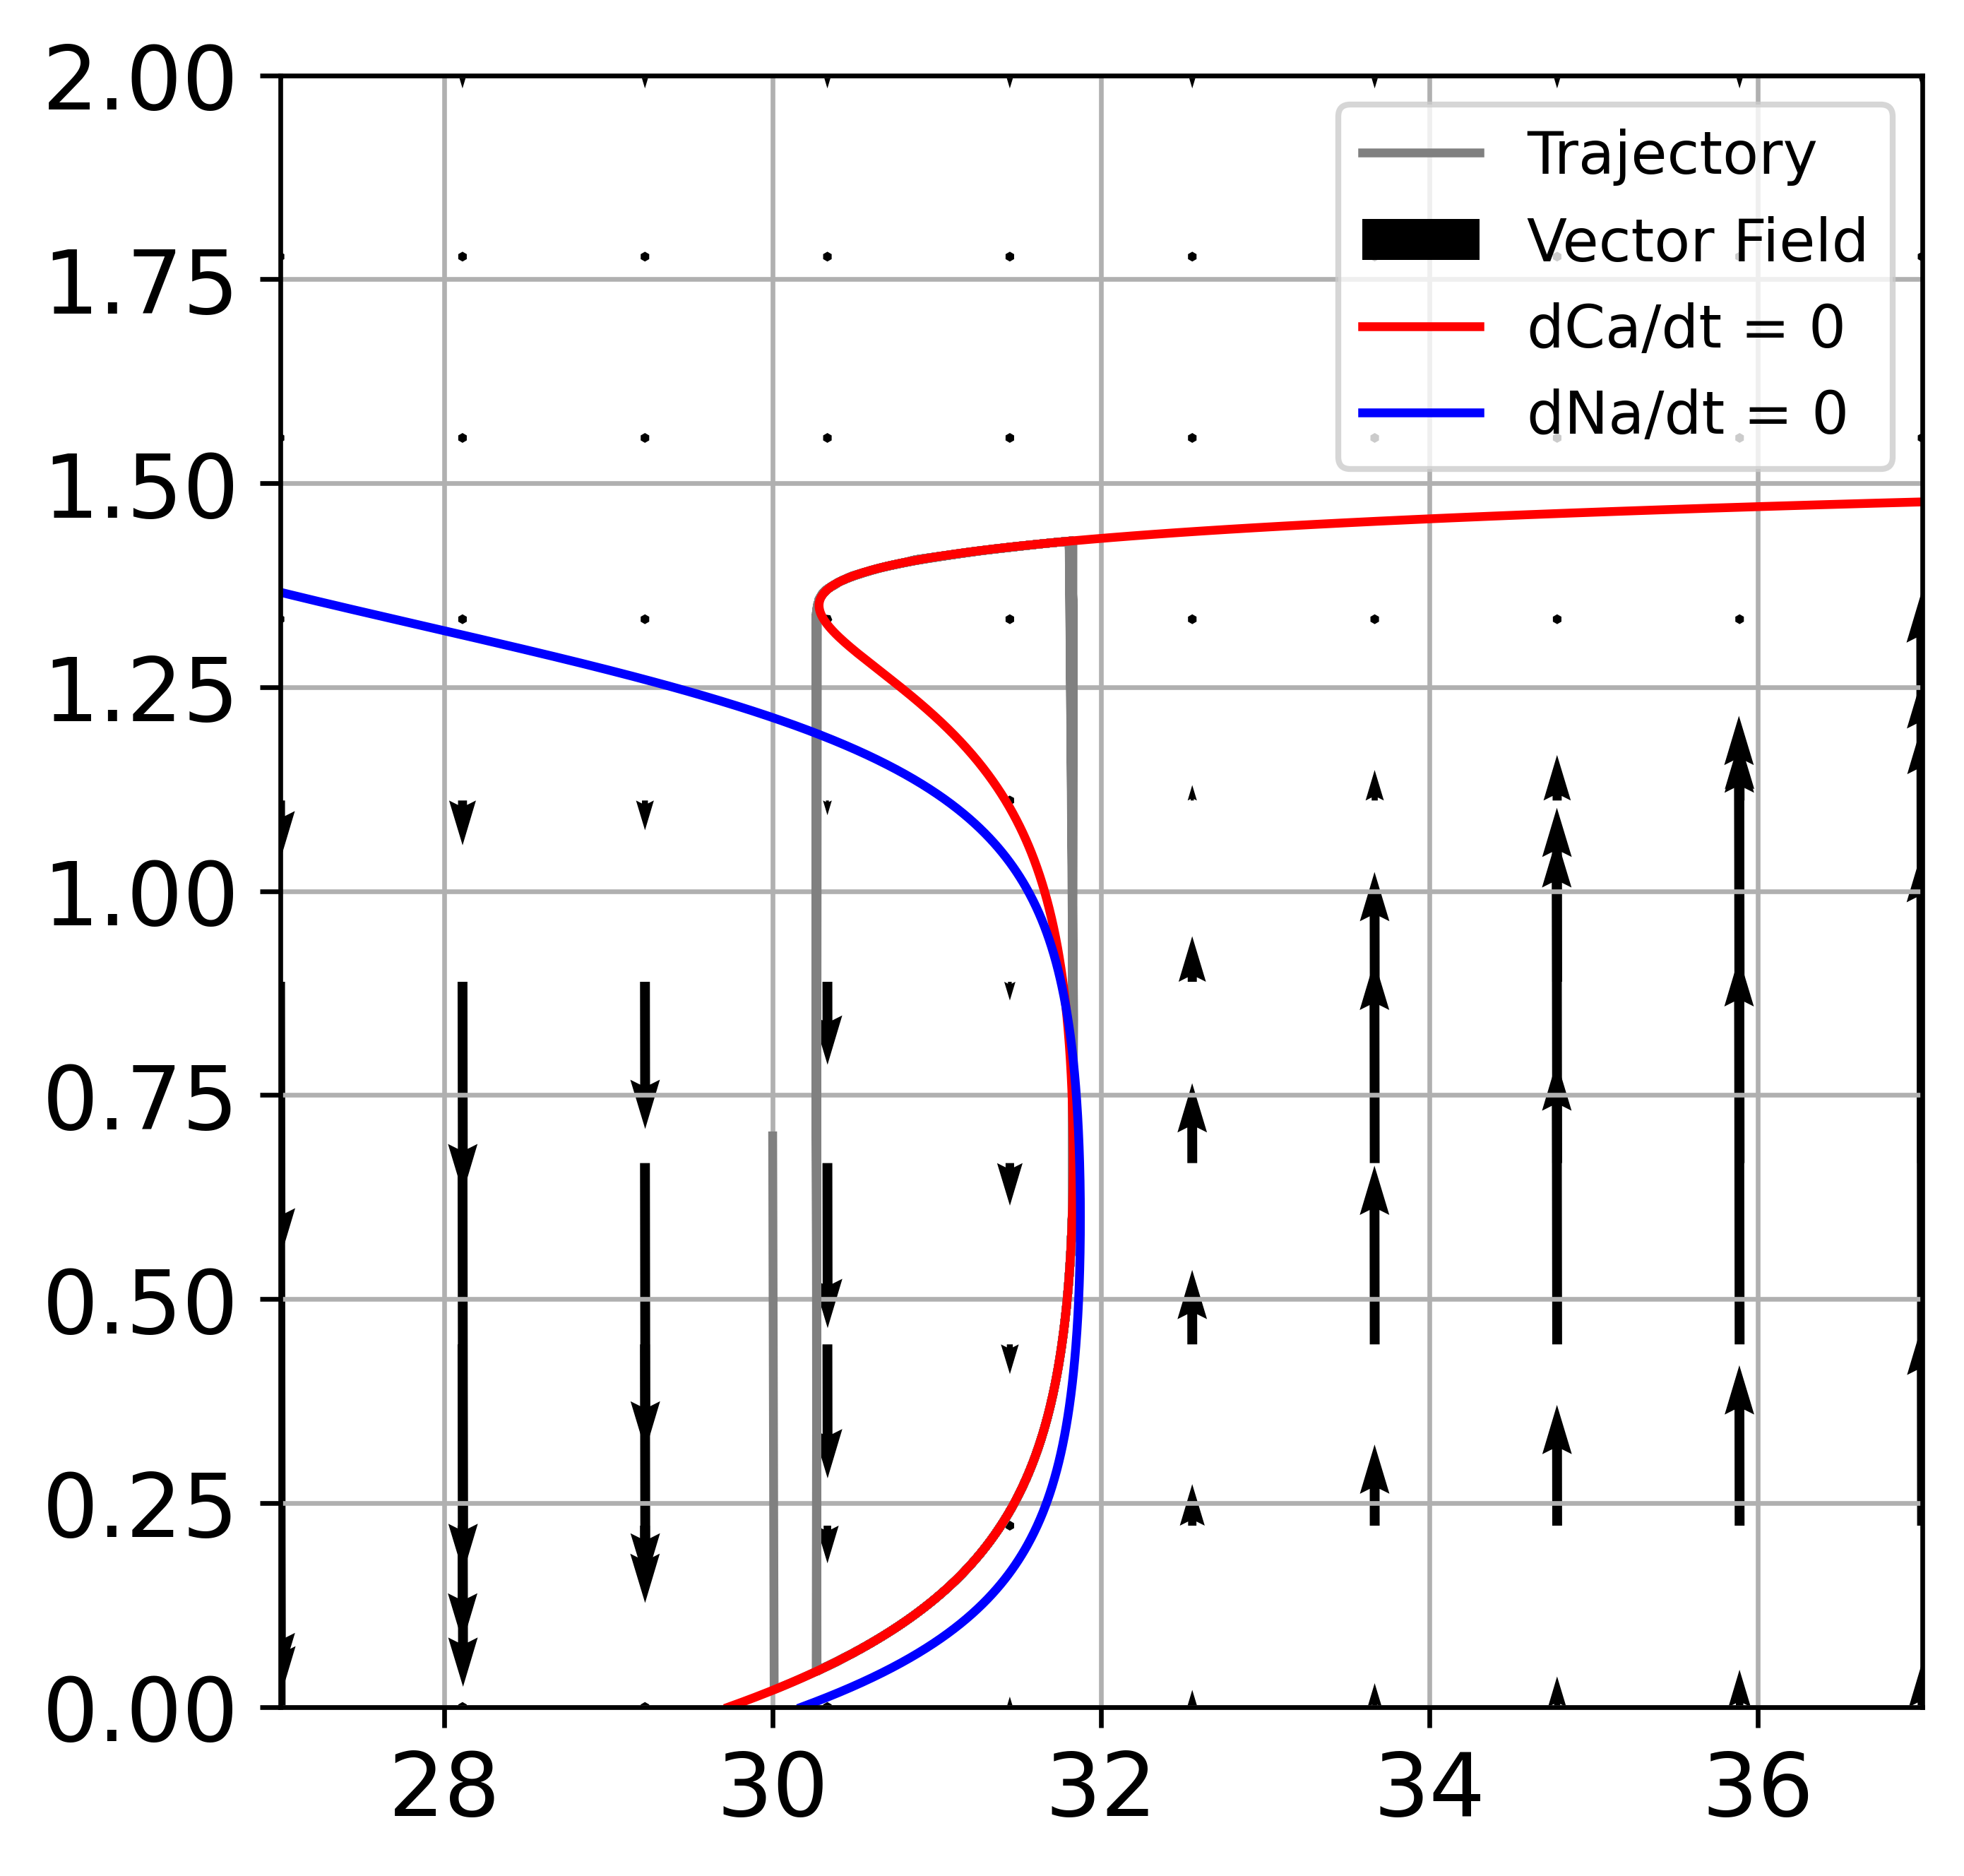

In [100]:
calcium_sodium(N=30,x0=32)

In [111]:
def calcium_sodium2(N=30,
                   C=0.7,
                   t_start=0,
                   t_end=30,
                   t_points=2000,
                   k=3,
                   Ki_inv=3,
                   Km_inv=0.5,
                   k_PMCA=0.8,
                   k_NCX=5,
                   Ck=0.6,
                   K_a=0.35,
                   k_s=0.06,
                   d=0.2,
                   g=0.6,
                   x0=32,
                   relative_rate=2000,
                   ):
    # Set x-axis limits for phase plane plot
    xlims = [x0 - 5, x0 + 5]
    tgrid = np.linspace(t_start, t_end, t_points)
    
    # Simulate the system
    df = simulate_Ca_Na(IC=[N, C],
                        t=tgrid,
                        k=k,
                        Ki_inv=Ki_inv,
                        Km_inv=Km_inv,
                        k_PMCA=k_PMCA,
                        k_NCX=k_NCX,
                        Ck=Ck,
                        K_a=K_a,
                        k_s=k_s,
                        d=d,
                        g=g,
                        x0=x0,
                        relative_rate=relative_rate,
                        )
    
    
    # Plot results
    fig, axs = plt.subplots(2, 1, figsize=(6, 5), dpi=600)
    df.plot(x="Time", y="Calcium", ax=axs[0], grid=True, legend=False)
    df.plot(x="Time", y="Sodium", ax=axs[1], grid=True, legend=False, color='green')
    
    axs[1].set_xlabel('')
    axs[0].set_xlabel('')
    axs[0].tick_params(labelsize=15)
    axs[1].tick_params(labelsize=15)

    # df.plot(x="Sodium", y="Calcium", ax=axs[1], grid=True, label='Trajectory', color='gray')

    # Add nullclines and vector fields to phase plane plot
    
    
    # Formatting
    
    
#     '''
#     # Plot results
#     fig, axs = plt.subplots(1, 2, figsize=(12, 5), dpi=600)
#     df.plot(x="Time", y="Calcium", ax=axs[0], grid=True, xlabel="Time", ylabel="Concentration")
#     df.plot(x="Time", y="Sodium", ax=axs[0], grid=True, xlabel="Time", ylabel="Concentration")

#     df.plot(x="Sodium", y="Calcium", ax=axs[1], grid=True, label='Trajectory', color='gray')

#     # Add nullclines and vector fields to phase plane plot
#     plot_nullclines_w_vectorfields(xlims=xlims,
#                     k=k,
#                     Ki_inv=Ki_inv,
#                     Km_inv=Km_inv,
#                     k_PMCA=k_PMCA,
#                     k_NCX=k_NCX,
#                     Ck=Ck,
#                     K_a=K_a,
#                     k_s=k_s,
#                     d=d,
#                     g=g,
#                     x0=x0,
#                     relative_rate=relative_rate)
    
#     # Formatting
#     axs[1].set_xlim(xlims)
#     axs[1].set_ylim(bottom=-0.05, top=2)
#     '''

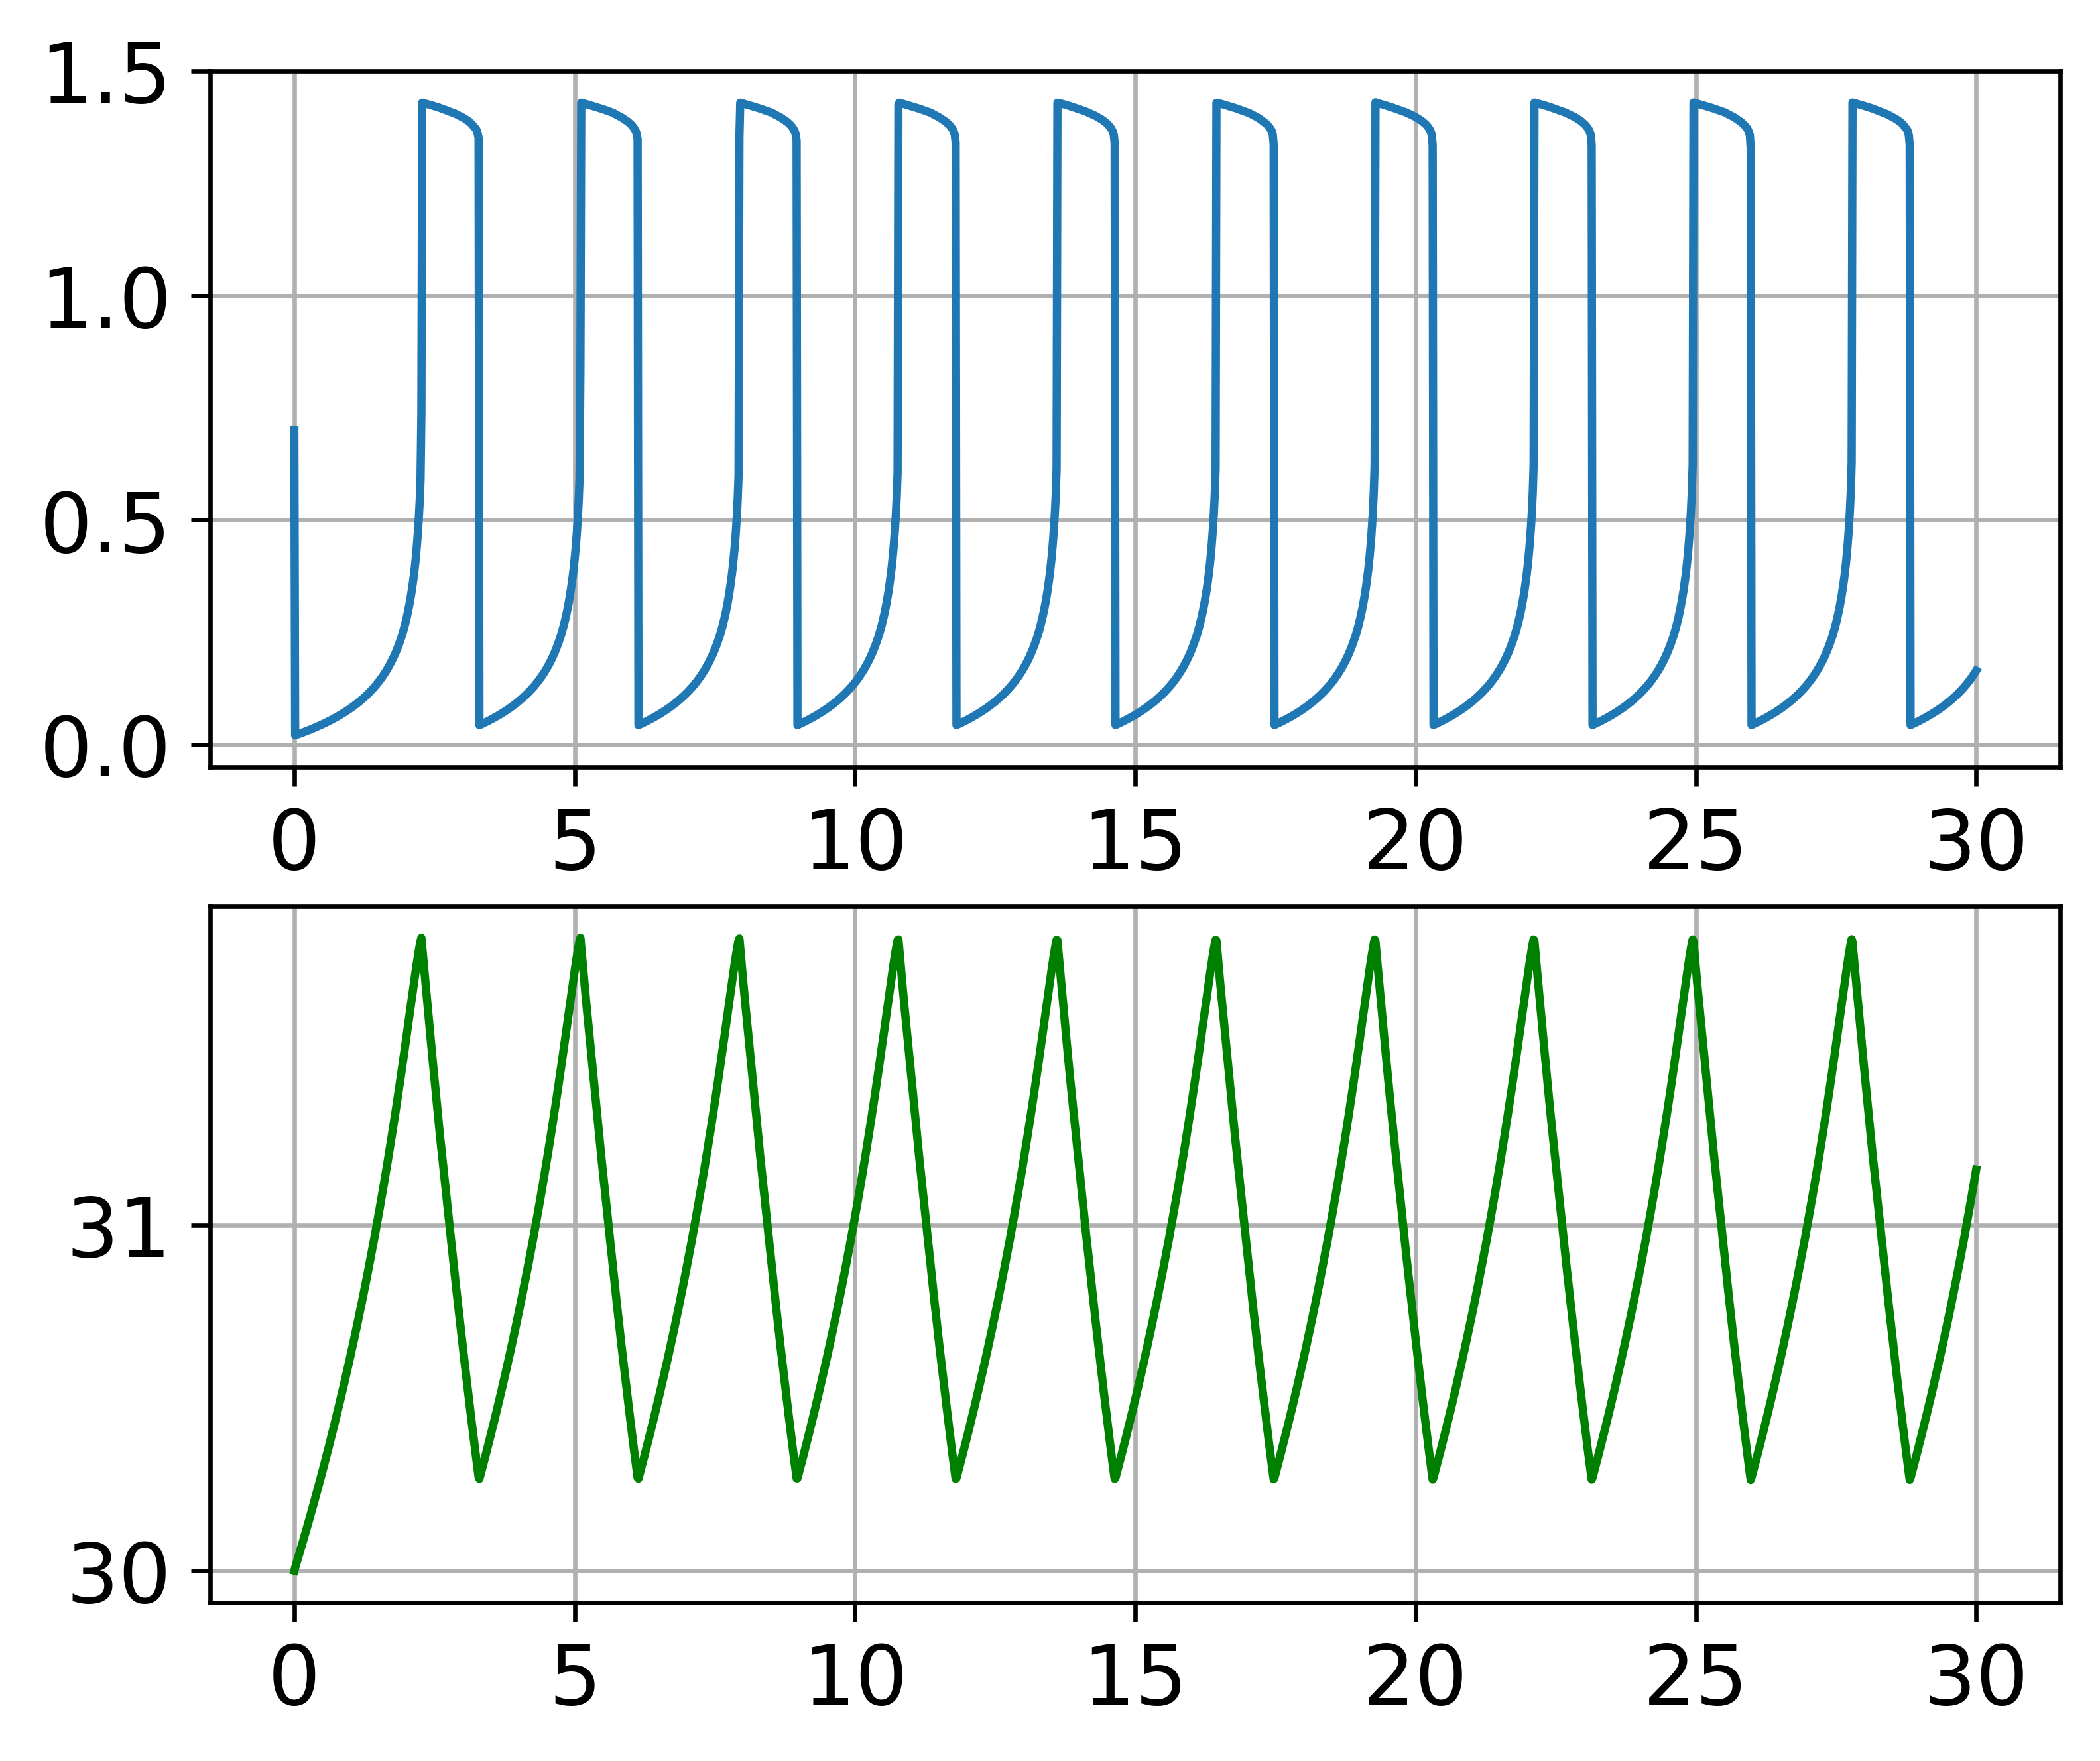

In [112]:
calcium_sodium2(N=30,x0=32)

## Simulate Stepwise change to param

In [117]:
def plot_two_nullclines(cond1, cond2):
    Cspan = np.linspace(0, 2, num=1000)
    C_nulcl1 = np.zeros(Cspan.shape[0])
    N_nulcl1 = np.zeros(Cspan.shape[0])
    
    k=cond1['k']     
    Ki_inv=cond1['Ki_inv']    
    Km_inv=cond1['Km_inv']       
    k_PMCA=cond1['k_PMCA']        
    k_NCX=cond1['k_NCX']      
    Ck=cond1['Ck']     
    K_a=cond1['K_a']   
    k_s=cond1['k_s']     
    d=cond1['d']
    g=cond1['g']
    x0=cond1['x0']
    relative_rate=cond1['relative_rate']
    
    # Compute nullclines
    for i in range(Cspan.shape[0]):
        C = Cspan[i]
        ip3r = (k * C) / (1 + Km_inv * C + Ki_inv * C ** 2) + g
        pmca = k_PMCA * C
        ncx_allo = k_NCX * math.exp(-1 * ((C - Ck) / K_a) ** 2)
        C_nulcl1[i] = -1 * (ip3r - pmca) / ncx_allo + x0
        Y_ncx = 3 * ncx_allo
        N_nulcl1[i] = (Y_ncx * x0 + d * x0) / (Y_ncx + k_s + d)

    # Nullclines
    plt.plot(C_nulcl1, Cspan, 'r')
    plt.plot(N_nulcl1, Cspan, 'b')
    
    C_nulcl2 = np.zeros(Cspan.shape[0])
    N_nulcl2 = np.zeros(Cspan.shape[0])
    k=cond2['k']     
    Ki_inv=cond2['Ki_inv']    
    Km_inv=cond2['Km_inv']       
    k_PMCA=cond2['k_PMCA']        
    k_NCX=cond2['k_NCX']      
    Ck=cond2['Ck']     
    K_a=cond2['K_a']   
    k_s=cond2['k_s']     
    d=cond2['d']
    g=cond2['g']
    x0=cond2['x0']
    relative_rate=cond2['relative_rate']
    
    for i in range(Cspan.shape[0]):
        C = Cspan[i]
        ip3r = (k * C) / (1 + Km_inv * C + Ki_inv * C ** 2) + g
        pmca = k_PMCA * C
        ncx_allo = k_NCX * math.exp(-1 * ((C - Ck) / K_a) ** 2)
        C_nulcl2[i] = -1 * (ip3r - pmca) / ncx_allo + x0
        Y_ncx = 3 * ncx_allo
        N_nulcl2[i] = (Y_ncx * x0 + d * x0) / (Y_ncx + k_s + d)

    # Nullclines
    plt.plot(C_nulcl2, Cspan, 'darkred', linewidth=2)
    plt.plot(N_nulcl2, Cspan, 'darkblue')
    

def calcium_sodium_piece(cond1, cond2, t, IC=[30,0.2]):
    # Set x-axis limits for phase plane plot
    xlims = [cond2['x0'] - 3, cond2['x0']  +.5]
    # tgrid = np.linspace(t_start, t_end, t_points)
    
    # Simulate the system
    df = simulate_Ca_Na_piece(cond1, cond2, IC, t)
        

    fig, axs = plt.subplots(2, 1, figsize=(6, 5), dpi=600)
    df.plot(x="Time", y="Calcium", ax=axs[0], grid=True, legend=False)
    df.plot(x="Time", y="Sodium", ax=axs[1], grid=True, legend=False)
    
    axs[1].set_xlabel('')
    axs[0].set_xlabel('')
    axs[0].tick_params(labelsize=15)
    axs[1].tick_params(labelsize=15)

    
    



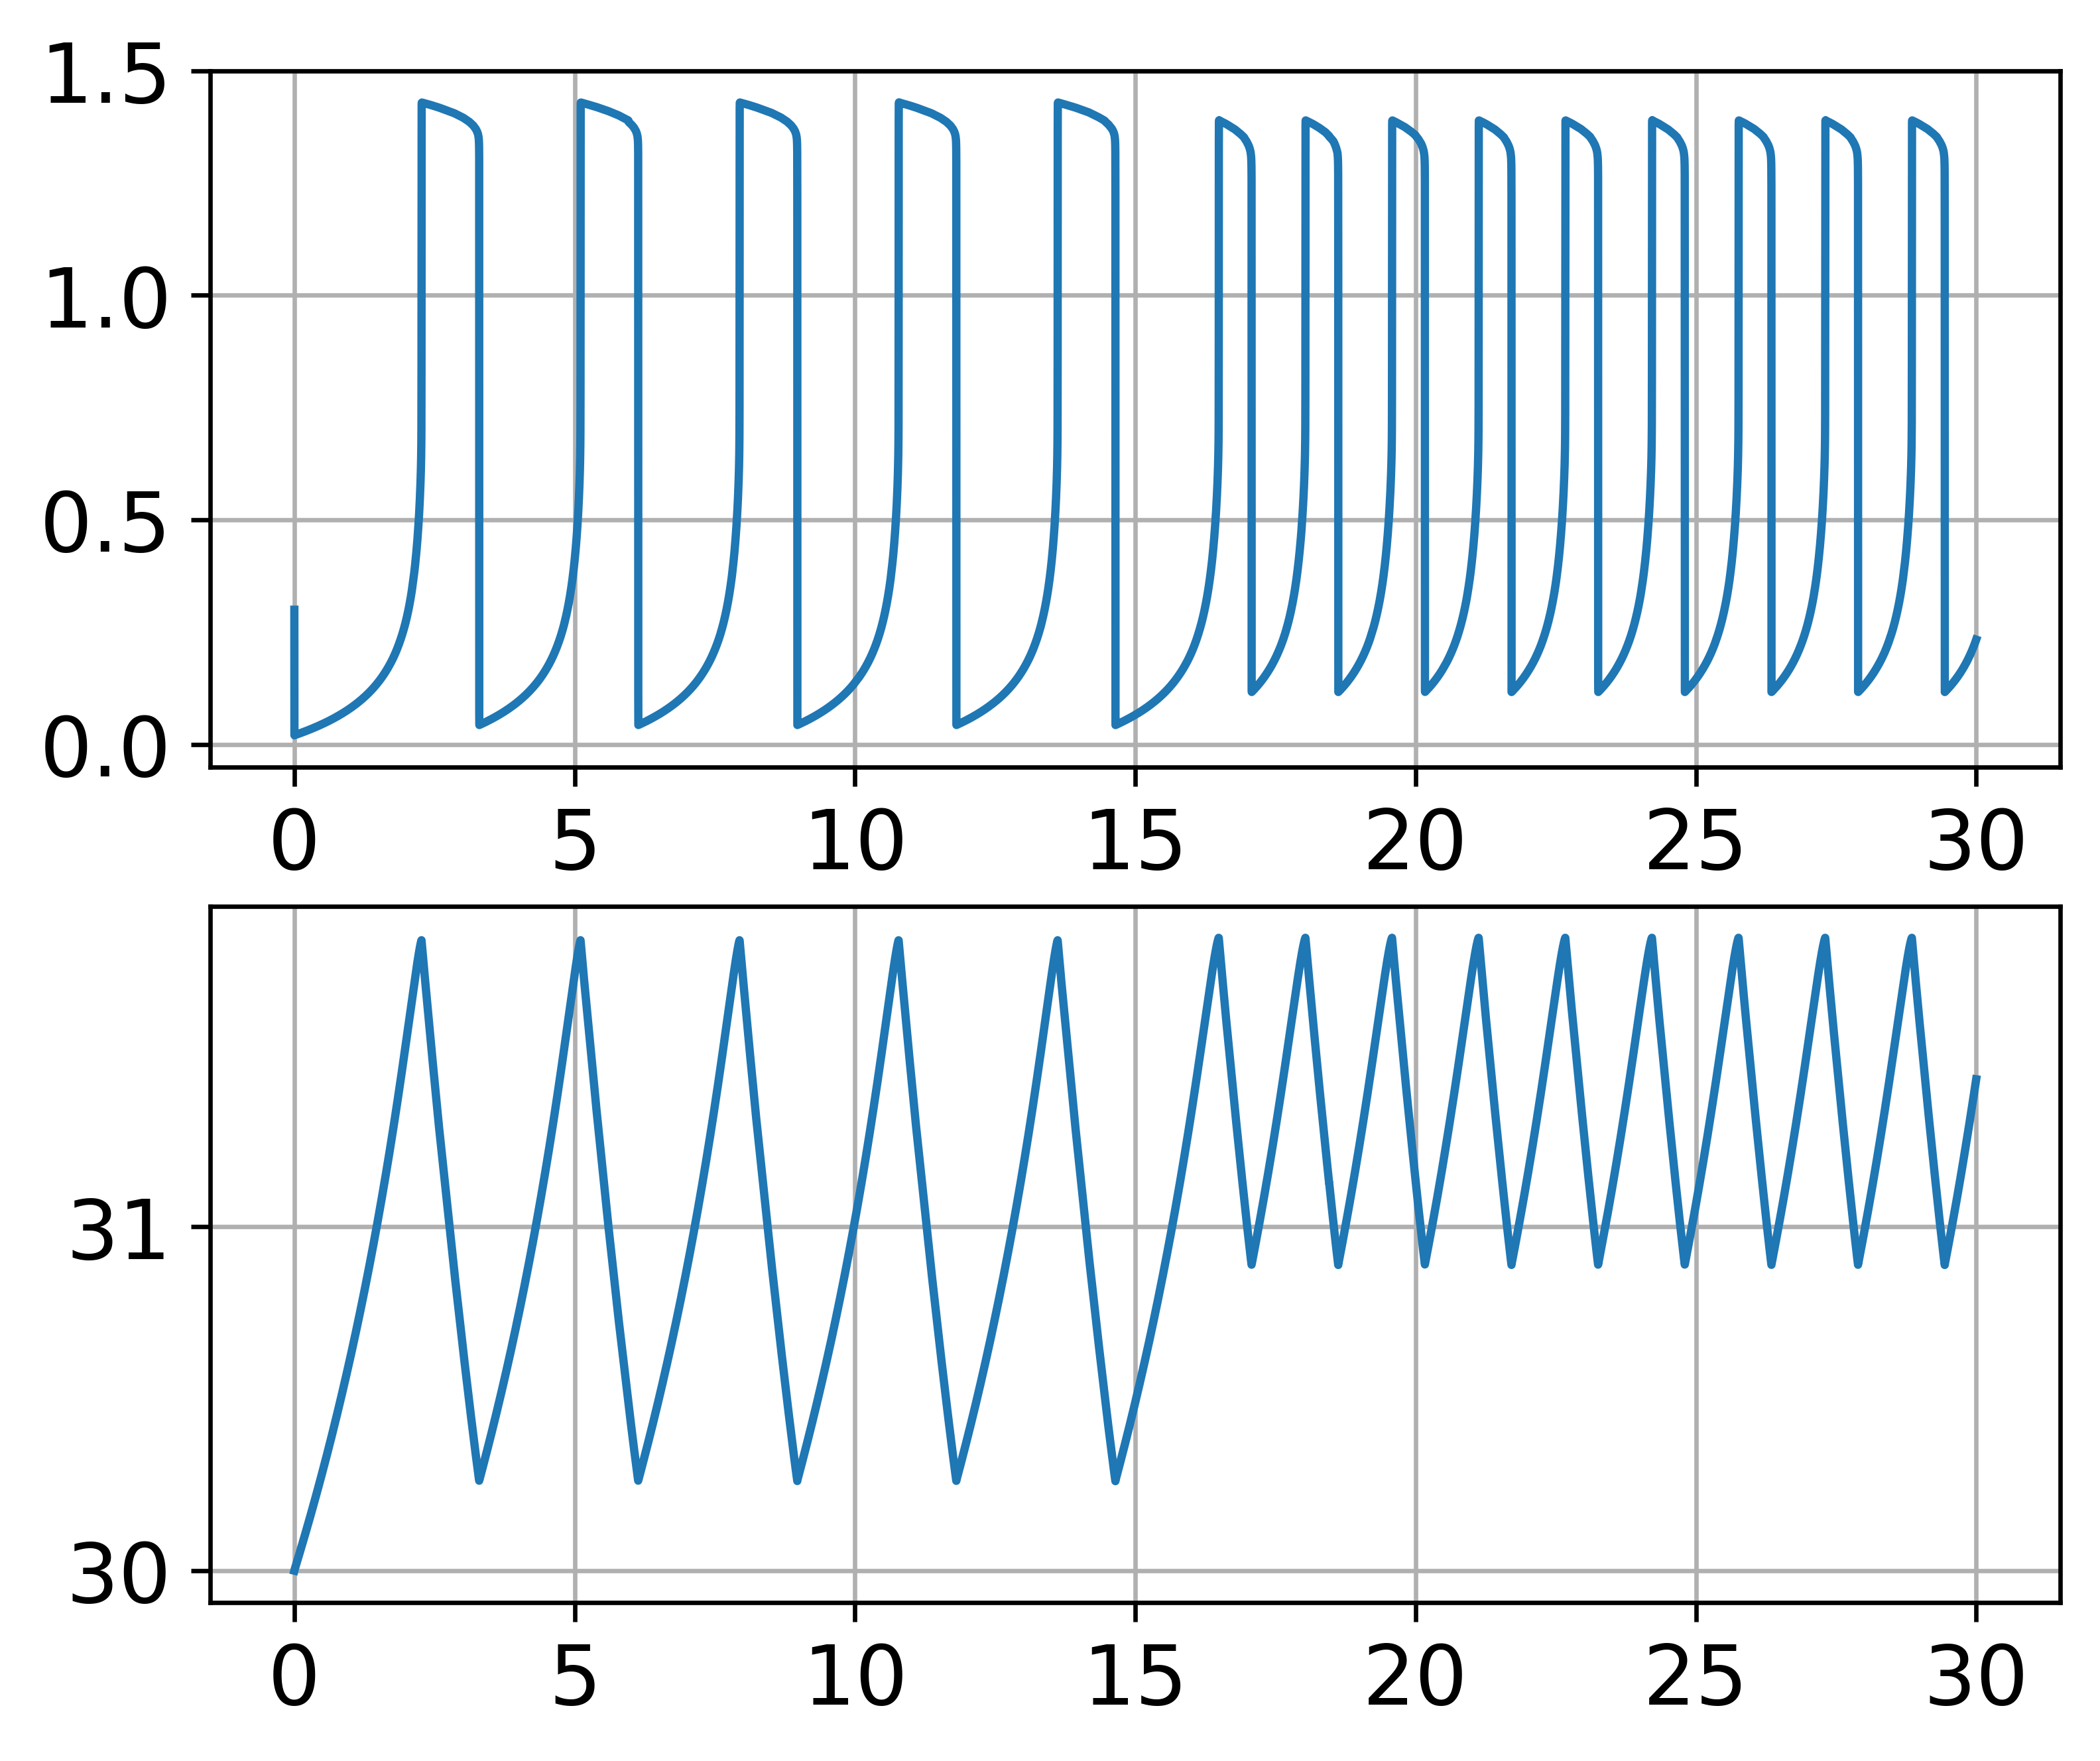

In [229]:
cond1 = {'k':3,     
    'Ki_inv':3,   
    'Km_inv':0.5,      
    'k_PMCA':0.8,       
    'k_NCX':5,     
    'Ck':0.6,    
    'K_a':0.35,  
    'k_s':0.06,     
    'd':0.2,
    'g':0.6,
    'x0':32.,     
    'relative_rate':2000}
cond2 = {'k':3,     
    'Ki_inv':3.3,   
    'Km_inv':0.5,      
    'k_PMCA':0.8,       
    'k_NCX':5,     
    'Ck':0.6,    
    'K_a':0.35,  
    'k_s':0.06,     
    'd':0.2,
    'g':0.6,
    'x0':32,     
    'relative_rate':2000}

calcium_sodium_piece(cond1, cond2,15, IC=[30,0.3])

In [234]:
def plot_two_nullclines(cond1, cond2):
    Cspan = np.linspace(0, 2, num=1000)
    C_nulcl1 = np.zeros(Cspan.shape[0])
    N_nulcl1 = np.zeros(Cspan.shape[0])
    
    k=cond1['k']     
    Ki_inv=cond1['Ki_inv']    
    Km_inv=cond1['Km_inv']       
    k_PMCA=cond1['k_PMCA']        
    k_NCX=cond1['k_NCX']      
    Ck=cond1['Ck']     
    K_a=cond1['K_a']   
    k_s=cond1['k_s']     
    d=cond1['d']
    g=cond1['g']
    x0=cond1['x0']
    relative_rate=cond1['relative_rate']
    
    # Compute nullclines
    for i in range(Cspan.shape[0]):
        C = Cspan[i]
        ip3r = (k * C) / (1 + Km_inv * C + Ki_inv * C ** 2) + g
        pmca = k_PMCA * C
        ncx_allo = k_NCX * math.exp(-1 * ((C - Ck) / K_a) ** 2)
        C_nulcl1[i] = -1 * (ip3r - pmca) / ncx_allo + x0
        Y_ncx = 3 * ncx_allo
        N_nulcl1[i] = (Y_ncx * x0 + d * x0) / (Y_ncx + k_s + d)

    # Nullclines
    plt.plot(C_nulcl1, Cspan, 'r')
    plt.plot(N_nulcl1, Cspan, 'b')
    
    C_nulcl2 = np.zeros(Cspan.shape[0])
    N_nulcl2 = np.zeros(Cspan.shape[0])
    k=cond2['k']     
    Ki_inv=cond2['Ki_inv']    
    Km_inv=cond2['Km_inv']       
    k_PMCA=cond2['k_PMCA']        
    k_NCX=cond2['k_NCX']      
    Ck=cond2['Ck']     
    K_a=cond2['K_a']   
    k_s=cond2['k_s']     
    d=cond2['d']
    g=cond2['g']
    x0=cond2['x0']
    relative_rate=cond2['relative_rate']
    
    for i in range(Cspan.shape[0]):
        C = Cspan[i]
        ip3r = (k * C) / (1 + Km_inv * C + Ki_inv * C ** 2) + g
        pmca = k_PMCA * C
        ncx_allo = k_NCX * math.exp(-1 * ((C - Ck) / K_a) ** 2)
        C_nulcl2[i] = -1 * (ip3r - pmca) / ncx_allo + x0
        Y_ncx = 3 * ncx_allo
        N_nulcl2[i] = (Y_ncx * x0 + d * x0) / (Y_ncx + k_s + d)

    # Nullclines
    plt.plot(C_nulcl2, Cspan, 'darkred', linewidth=2)
    plt.plot(N_nulcl2, Cspan, 'darkblue')
    

def calcium_sodium_piece2(cond1, cond2, t, IC=[30,0.2]):
    # Set x-axis limits for phase plane plot
    xlims = [cond2['x0'] - 2, cond2['x0']  +.5]
    # tgrid = np.linspace(t_start, t_end, t_points)
    
    # Simulate the system
    df = simulate_Ca_Na_piece(cond1, cond2, IC, t)
    
    
    # Plot results
    fig, axs = plt.subplots(1, 2, figsize=(12, 5), dpi=1200)
    df.plot(x="Time", y="Calcium", ax=axs[0], grid=True, xlabel="Time", ylabel="Concentration")
    df.plot(x="Time", y="Sodium", ax=axs[0], grid=True, xlabel="Time", ylabel="Concentration")

    # df.plot(x="Sodium", y="Calcium", ax=axs[1], grid=True, xlabel="Sodium", ylabel="Calcium",color='gray', legend=None)

    # Add nullclines and vector fields to phase plane plot
    plot_two_nullclines(cond1, cond2)
    
    
    # Formatting
    axs[1].set_xlim(xlims)
    axs[1].set_ylim(bottom=-0.05, top=1.5)
    axs[1].tick_params(labelsize=15)
    axs[1].set_xlabel('')
    axs[1].set_ylabel('')
    axs[1].grid(True)
    



In [235]:
calcium_sodium_piece2(cond1, cond2,15, IC=[30,0.3])